# Dataset sul Traffico di Rete

Il dataset che useremo in questa esercitazione contiene caratteristiche estratte da sessioni di traffico di rete, progettate per l'analisi e il rilevamento di malware basato sul comportamento della rete. Le caratteristiche sono organizzate in diverse categorie funzionali.

## Categorie principali di caratteristiche

### Informazioni sulla sessione
- **Informazioni temporali**: `start`, `duration`, `cap_date`, `daysTime`, `weekDay`
- **Informazioni di connessione**: Indirizzi IP e porte (`...ip`, `...port`)
- **Etichette**: `label`, `labelSS` (classificazione del malware)

### Metriche TCP/IP
- **Statistiche pacchetti**: Conteggio pacchetti (`packets_...`), dimensioni (`packetsize...`), rapporti (`packetsAB_ratio`)
- **Flag TCP**: Pacchetti ACK (`ack_...`), PUSH (`push_...`), RESET (`reset_...`), URG (`urg_...`)
- **Tempi di arrivo**: Tempi tra pacchetti (`packetinterarrivel_...`)
- **Time-to-live**: Valori TTL per pacchetti client/server (`ttl_...`, `ttlA...`, `ttlB...`)
- **Analisi TCP**: Pacchetti persi, ritrasmessi (`tcpanalysis...`)
- **Bytes trasferiti**: Totali e rapporti (`bytes_...`, `bytesAB_ratio`)

### Protocollo HTTP
- **Richieste HTTP**: Metodi GET/POST (`http_GET`, `http_POST`), conteggi (`httpcount...`)
- **Bytes HTTP**: Dimensioni richieste/risposte (`httpreqbytes_...`, `httprespbytes_...`)
- **Tempi HTTP**: Tempi di risposta (`httptime...`), tempi tra richiesta e risposta (`httpinterarrivel_...`)
- **Cookie**: Conteggio e valori (`httpcookiecount`, `httpcookievalues_...`)
- **Host dominante**: URL, rank Alexa, tipo di browser (`httpdom...`)
- **Classificazione URL**: Identificatori per CDN, ad, cloud, ecc. (`iscdnhttp`, `isadhttp`, `iscloudhttp`, etc.)

### Protocollo DNS
- **Risposta DNS**: Conteggio indirizzi, risposte, flag (`dnscountaddresses`, `dns_flag`)
- **Hostname DNS**: Nome host, TTL (`dnshostname`, `dnsminttl`)
- **Tempi DNS**: Tempo di risposta (`dns_time`)
- **Rank Alexa**: Rank del server nella risposta DNS (`dns_alexaRank`)

### Protocollo SSL/TLS
- **Handshake SSL**: Durata (`sslhandshakeduration_...`)
- **Bytes SSL**: Bytes richiesta/risposta (`sslreqbytes_...`, `sslrespbytes_...`)
- **Certificati**: Conteggio, rapporti (`sslcountcertificates`, `sslratio...`)
- **Cifrari e algoritmi**: Conteggio cifrari supportati (`sslcountclient_...`, `sslcountserver_...`)
- **Versioni SSL**: Numero di versioni, versione dominante (`ssldomserver_ciphersuite`, `ssldomserver_compression`)

### Informazioni geografiche e di routing
- **ASN**: Numero di sistemi autonomi (`asn_...`)
- **Paesi**: Numero di paesi per client/server (`country_...`)


# Obiettivo
  Partendo dalle varie features che corrispondono a come un dispositivo interagisce nella rete, bisogna classificare la tipologia di dispositivo (`device_category`)

In [31]:
import pandas as pd
df = pd.read_csv('iot_device_test.csv')

### Stampiamo le colonne

In [32]:
df.columns

Index(['ack', 'ack_A', 'ack_B', 'bytes', 'bytes_A', 'bytes_A_B_ratio',
       'bytes_B', 'ds_field_A', 'ds_field_B', 'duration',
       ...
       'suffix_is_co.il', 'suffix_is_com', 'suffix_is_com.sg',
       'suffix_is_else', 'suffix_is_empty_char_value',
       'suffix_is_googleapis.com', 'suffix_is_net', 'suffix_is_org',
       'suffix_is_unresolved', 'device_category'],
      dtype='str', length=298)

### Vediamo che tipologia di valori dobbiamo classificare

In [33]:
df["device_category"]

0      baby_monitor
1      baby_monitor
2      baby_monitor
3      baby_monitor
4      baby_monitor
           ...     
895           watch
896           watch
897           watch
898           watch
899           watch
Name: device_category, Length: 900, dtype: str

In [34]:
#Vediamo quali sono i device che abbiamo
df["device_category"].unique()

<StringArray>
[   'baby_monitor',          'lights',   'motion_sensor', 'security_camera',
  'smoke_detector',          'socket',      'thermostat',              'TV',
           'watch']
Length: 9, dtype: str

In [35]:
#Vediamo come sono distribuiti i device
df["device_category"].value_counts()
#Abbiamo quindi un dataset bilanciato.

device_category
baby_monitor       100
lights             100
motion_sensor      100
security_camera    100
smoke_detector     100
socket             100
thermostat         100
TV                 100
watch              100
Name: count, dtype: int64

In [36]:
# Verifica dei valori NaN
nan_counts = df.isna().sum()
print(f"Colonne con valori NaN:")
print(nan_counts[nan_counts > 0])

Colonne con valori NaN:
Series([], dtype: int64)


In [37]:
#Per ogni categoria dobbiamo assegnare un id che funziona da label per la classificazione
devices = df["device_category"].unique()


In [38]:
device_id_mapping = {i: device for i, device in enumerate(devices)}
print(device_id_mapping)

{0: 'baby_monitor', 1: 'lights', 2: 'motion_sensor', 3: 'security_camera', 4: 'smoke_detector', 5: 'socket', 6: 'thermostat', 7: 'TV', 8: 'watch'}


In [39]:
df['device_category'] = df['device_category'].map({device: i for i, device in enumerate(devices)})


In [40]:
df['device_category']

0      0
1      0
2      0
3      0
4      0
      ..
895    8
896    8
897    8
898    8
899    8
Name: device_category, Length: 900, dtype: int64

suffix_is_org                        0.0
suffix_is_net                        0.0
suffix_is_googleapis.com             0.0
http_cookie_values_entropy           0.0
http_cookie_values_var               0.0
http_cookie_values_stdev             0.0
subdomain_is_whp.hou9.cold.extweb    0.0
subdomain_is_www                     0.0
subdomain_is_feeds                   0.0
subdomain_is_h10141.www1             0.0
subdomain_is_img                     0.0
subdomain_is_whp.aus1.cold.extweb    0.0
B_port_is_9543                       0.0
subdomain_is_99sets                  0.0
subdomain_is_ccc                     0.0
B_port_is_8280                       0.0
is_img_http                          0.0
is_ad_http                           0.0
B_port_is_54975                      0.0
B_port_is_5223                       0.0
http_req_bytes_stdev                 0.0
http_req_bytes_var                   0.0
http_req_bytes_entropy               0.0
B_port_is_5222                       0.0
http_has_locatio

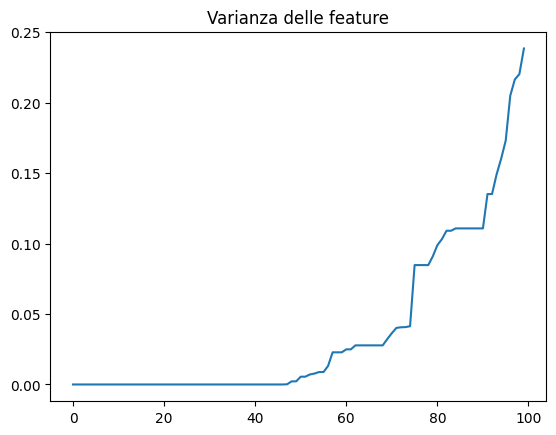

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


from sklearn.feature_selection import VarianceThreshold

X = df.drop(columns=['device_category'])
y = df['device_category']

# calcolo i valori di varianza e li ordiniamo dal più piccolo al più grande
variances = X.var().sort_values()
print(variances.head(30))   # le più basse

print(variances.tail(5))   # le più alte

plt.plot(variances.values[:100])
plt.title("Varianza delle feature")
plt.show()

In [42]:
threshold = 0.02
selected_features = variances[variances > threshold].index
X_var = X[selected_features]

X_var

,domain_is_proteussensor,is_cloud_http,subdomain_is_www.cloud,http_POST,http_has_referrer,http_cookie_values_thirdQ,http_cookie_values_max,http_cookie_values_median,http_cookie_values_min,http_cookie_values_firstQ,...,http_dom_host_alexaRank,http_time_min,http_time_firstQ,http_time_avg,http_time_median,http_time_thirdQ,http_time_max,ssl_dom_server_name_alexaRank,http_time_sum,http_time_var
0,0,0,0,0,0,0,0,0,0,0,...,2147483647,0.0,0.0,0.0,0.0,0.0,0.0,139,0.0,0.0
1,0,0,0,0,0,0,0,0,0,0,...,2147483647,0.0,0.0,0.0,0.0,0.0,0.0,139,0.0,0.0
2,0,0,0,0,0,0,0,0,0,0,...,2147483647,0.0,0.0,0.0,0.0,0.0,0.0,139,0.0,0.0
3,0,0,0,0,0,0,0,0,0,0,...,2147483647,0.0,0.0,0.0,0.0,0.0,0.0,139,0.0,0.0
4,0,0,0,0,0,0,0,0,0,0,...,2147483647,0.0,0.0,0.0,0.0,0.0,0.0,139,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
895,0,0,0,0,0,0,0,0,0,0,...,2147483647,0.0,0.0,0.0,0.0,0.0,0.0,1779,0.0,0.0
896,0,0,0,0,0,0,0,0,0,0,...,2147483647,0.0,0.0,0.0,0.0,0.0,0.0,1779,0.0,0.0
897,0,0,0,0,0,0,0,0,0,0,...,2147483647,0.0,0.0,0.0,0.0,0.0,0.0,1779,0.0,0.0
898,0,0,0,0,0,0,0,0,0,0,...,2147483647,0.0,0.0,0.0,0.0,0.0,0.0,1779,0.0,0.0


### Proviamo a filtrare qualche colonna in base al modulo della correlazione

ssl_count_client_mac_algs          0.544407
reset_A                            0.493785
ssl_req_bytes_min                  0.399735
ttl_B_min                          0.380410
ttl_thirdQ                         0.370152
reset_B                            0.358092
ttl_B_stdev                        0.334591
ttl_max                            0.333855
packet_size_A_thirdQ               0.325068
ssl_dom_version                    0.320143
ssl_ratio_server_name              0.319185
ssl_count_transactions             0.319185
ssl_count_server_compression       0.319185
is_ssl                             0.319185
ssl_count_client_compressions      0.319185
ssl_count_version                  0.319185
ssl_count_server_name              0.319185
ssl_count_server_elliptic_curve    0.319185
ssl_count_server_ciphersuite       0.319185
packet_size_A_entropy              0.318804
dtype: float64


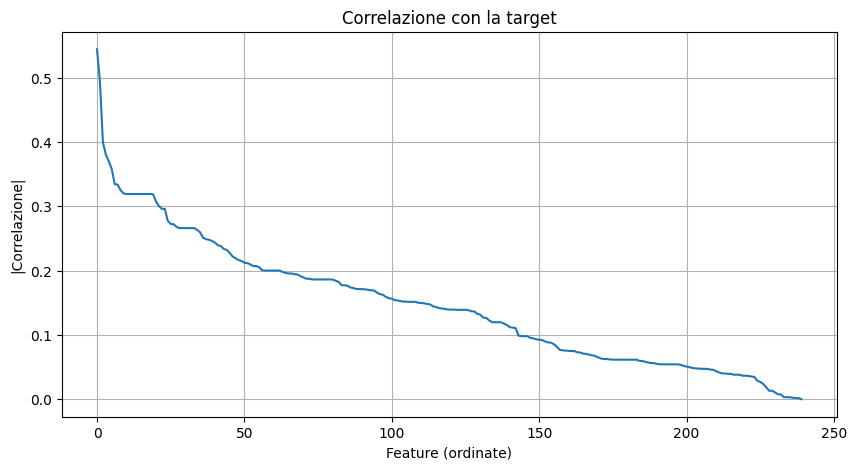

In [43]:
# Calcolo della correlazione tra ogni feature e la target
corr_with_target = X_var.corrwith(y)

# Prendo il valore assoluto (non mi interessa il segno)
corr_with_target = corr_with_target.abs()

# Ordino le feature dalla più correlata alla meno correlata
corr_with_target = corr_with_target.sort_values(ascending=False)

# Stampo le più importanti
print(corr_with_target.head(20))

plt.figure(figsize=(10,5))
plt.plot(corr_with_target.values)
plt.title("Correlazione con la target")
plt.xlabel("Feature (ordinate)")
plt.ylabel("|Correlazione|")
plt.grid(True)
plt.show()

In [44]:
# Seleziono le top-k feature più correlate
top_k = 50

selected_features = corr_with_target.head(top_k).index

# Dataset finale
cleaned_df = X_var[selected_features]
# Aggiungo la variabile target
cleaned_df["device_category"] = y

# Stampo le dimensioni del nuovo dataframe
print(f"Dimensioni del nuovo DataFrame: {cleaned_df.shape}")

# Stampo il numero di feature selezionate (senza la target)
print(f"Features selezionate: {len(selected_features)}")

Dimensioni del nuovo DataFrame: (900, 51)
Features selezionate: 50


In [45]:
cleaned_df.head()

,ssl_count_client_mac_algs,reset_A,ssl_req_bytes_min,ttl_B_min,ttl_thirdQ,reset_B,ttl_B_stdev,ttl_max,packet_size_A_thirdQ,ssl_dom_version,...,B_port_is_else,packet_inter_arrivel_A_min,bytes_A_B_ratio,ssl_dom_server_ciphersuite,packet_size_B_avg,ssl_req_bytes_firstQ,ttl_B_var,packet_inter_arrivel_firstQ,packet_inter_arrivel_B_max,device_category
0,1,2,32,33,225.0,0,45.201365,225,85.5,769,...,1,0.0,1.135096,49171,378.444444,32.0,2043.163399,0.000078,0.507894,0
1,1,2,32,33,226.0,0,45.437057,226,85.5,769,...,1,0.0,1.135096,49171,378.444444,32.0,2064.526144,0.000027,0.527756,0
2,1,2,32,35,228.0,0,45.463948,228,85.5,769,...,1,0.0,1.124640,49171,378.444444,32.0,2066.970588,0.000024,0.523921,0
3,1,2,32,34,228.0,0,45.699645,228,85.5,769,...,1,0.0,1.124640,49171,378.444444,32.0,2088.457516,0.000020,0.696363,0
4,1,2,32,34,227.0,0,42.095300,227,85.5,769,...,1,0.0,1.163949,49171,324.380952,32.0,1772.014286,0.000095,0.555956,0


### ATTENZIONE: MUTUAL_INFO_CLASSIF usa info anche del test.. andrebbe fatta dopo la divisione del dataset per evitare data leakage

In [46]:
from sklearn.feature_selection import mutual_info_classif
import pandas as pd

# Target
y = df['device_category']  # usa la colonna già encodata

# Feature dopo variance threshold
X = X_var.copy()

mi_scores = mutual_info_classif(X, y, random_state=42)

mi_series = pd.Series(mi_scores, index=X.columns)
mi_series = mi_series.sort_values(ascending=False)

top50_mi = mi_series.head(50).index.tolist()
top50_corr = [col for col in cleaned_df.columns if col != 'device_category']

# Feature in comune
common_features = set(top50_corr).intersection(set(top50_mi))

# Solo correlazione
only_corr = set(top50_corr) - set(top50_mi)

# Solo mutual information
only_mi = set(top50_mi) - set(top50_corr)

print(f"Feature comuni: {len(common_features)}")
print(f"Solo correlazione: {len(only_corr)}")
print(f"Solo mutual information: {len(only_mi)}")

Feature comuni: 10
Solo correlazione: 40
Solo mutual information: 40


In [47]:
from sklearn.model_selection import train_test_split

#utilizzando il df pulito dalla correlazione
# X = cleaned_df.drop(columns=['device_category'])
# y = cleaned_df['device_category']

#utilizzando il df pulito dalla mutual information
X = X_var[top50_mi]
y = df['device_category']

# Split train+val / test - 500 istanze: 400 temp e 100 test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Split train / validation - delle 400 istanze temp faccio un'altra suddivisione (25%): 300 train e 100 validazione
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.25,  # 0.25 * 0.8 = 0.2
    random_state=42,
    stratify=y_temp
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (540, 50)
Validation: (180, 50)
Test: (180, 50)


In [48]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [49]:
import numpy as np
import matplotlib.pyplot as plt

class LinearSVM:
    """
    Implementazione di SVM lineare utilizzando l'algoritmo SMO (Sequential Minimal Optimization)
    per risolvere il problema duale del Lagrangiano.
    
    Questo algoritmo risolve il problema duale:
    max Σ α_i - (1/2) Σ Σ α_i α_j y_i y_j (x_i · x_j)
    vincoli: 
    Σ α_i y_i = 0 
    0 ≤ α_i ≤ C

    Idea di SMO:
    invece di ottimizzare tutti gli alpha insieme, ne aggiorniamo due alla volta.
    Questo permette di rispettare il vincolo Σ α_i y_i = 0 e rende il problema gestibile.
    
    Parametri:
    -----------
    C : float, default=1.0
        Parametro di regolarizzazione per il margine morbido.
    tol : float, default=1e-3
        Tolleranza per i criteri di convergenza.
    max_passes : int, default=5
        Numero massimo di passi senza cambiamenti significativi.
    max_iter : int, default=1000
        Numero massimo di iterazioni.
    """
    
    def __init__(self, C=1.0, tol=1e-3, max_passes=5, max_iter=1000):
        self.C = C
        self.tol = tol
        self.max_passes = max_passes
        self.max_iter = max_iter
        #Moltiplicatori di Lagrange del problema duale
        self.alphas = None
        self.b = 0     #bias della frontiera
        self.w = None
        #Informazioni sui support vectors
        self.support_vector_indices = None
        self.support_vectors = None
        self.support_vector_labels = None
        #Cache degli errori
        self.errors = None
    
    #utilizzati dentro l'algoritmo SMO
    def _compute_error(self, i):
        """Calcola l'errore per il punto i"""
        f_i = np.dot(self.w, self.X[i]) + self.b
        return f_i - self.y[i]
        
    def _select_second_alpha(self, i):
        """
        Sceglie il secondo alpha (indice j) da ottimizzare insieme ad alpha_i.

        Euristica:
        scegliamo il punto che ha un errore il più diverso possibile da E_i,
        così l'aggiornamento tende a essere più efficace.

        Se E_i è positivo, cerchiamo l'errore più piccolo.
        Se E_i è negativo, cerchiamo l'errore più grande.
        """
        errors = self.errors.copy()
        # Escludiamo l'indice i: j deve essere diverso da i
        valid_indices = np.arange(len(errors)) != i
        errors_valid = errors[valid_indices]
        indices_valid = np.arange(len(errors))[valid_indices]
        
        # Cerchiamo un errore "opposto" a quello di i per massimizzare il passo
        if self.errors[i] > 0:
            j = indices_valid[np.argmin(errors_valid)]
        else:
            j = indices_valid[np.argmax(errors_valid)]
        
        return j
    
    def fit(self, X, y):
        """
        Addestra il modello SVM sui dati di training.
        
        Parametri:
        ----------
        X : array-like, shape (n_samples, n_features)
            Training vectors.
        y : array-like, shape (n_samples,)
            Target values, deve contenere -1 e 1 o 0 e 1.
        
        Returns:
        --------
        self : oggetto
            Ritorna self.
        """
        n_samples, n_features = X.shape
        
        # La SVM duale lavora naturalmente con etichette in {-1, +1}
        self.y_original = y.copy()
        self.y = np.where(y <= 0, -1, 1)
        self.X = X
        
        # Inizializzazione:
        # - tutti gli alpha a zero
        # - w nullo
        # - bias nullo
        self.alphas = np.zeros(n_samples)
        self.w = np.zeros(n_features)
        self.b = 0
        
        # Inizializziamo gli errori
        self.errors = np.zeros(n_samples)
        for i in range(n_samples):
            self.errors[i] = self._compute_error(i)
        
        print("Inizio addestramento SVM...")
        
        # Implementazione dell'algoritmo SMO - variabili di controllo SMO
        num_changed = 0
        examine_all = True
        passes = 0
        
        iterations = 0

        while (passes < self.max_passes) and (iterations < self.max_iter):
            num_changed = 0

            if examine_all:
                indices = range(n_samples)
            else:
                indices = np.where((self.alphas > 0) & (self.alphas < self.C))[0]

            for i in indices:
                num_changed += self._examine_example(i)

            if examine_all:
                examine_all = False
            elif num_changed == 0:
                examine_all = True

            if num_changed == 0:
                passes += 1
            else:
                passes = 0

            iterations += 1
        
        # Identifichiamo i support vector
        # I support vectors sono i punti con alpha > 0
        # In pratica usiamo una soglia per evitare problemi numerici.
        sv_indices = np.where(self.alphas > self.tol)[0]
        self.support_vector_indices = sv_indices
        self.support_vectors = X[sv_indices]
        self.support_vector_labels = self.y[sv_indices]
        
        print(f"Addestramento completato in {iterations} iterazioni!")
        print(f"Passate finali senza cambiamenti: {passes}")
        print(f"Numero di support vectors: {len(sv_indices)} su {n_samples} punti ({len(sv_indices)/n_samples*100:.1f}%)")
        print(f"Norma del vettore w: {np.linalg.norm(self.w):.6f}")
        
        return self
    
    def _examine_example(self, i):
        """Esamina un esempio e aggiorna gli alpha se necessario"""
        y_i = self.y[i]
        alpha_i = self.alphas[i]
        E_i = self.errors[i]
        r_i = E_i * y_i

        # Verifica violazione KKT
        if not ((r_i < -self.tol and alpha_i < self.C) or 
                (r_i > self.tol and alpha_i > 0)):
            return 0

        # 1. Prova prima il j scelto dall'euristica
        j = self._select_second_alpha(i)
        if self._take_step(i, j):
            return 1

        # 2. Se fallisce, prova tutti gli alpha non-bound
        non_bound_indices = np.where((self.alphas > 0) & (self.alphas < self.C))[0]
        np.random.shuffle(non_bound_indices)

        for j in non_bound_indices:
            if j != i and self._take_step(i, j):
                return 1

        # 3. Se fallisce ancora, prova tutti gli esempi
        all_indices = np.arange(len(self.alphas))
        np.random.shuffle(all_indices)

        for j in all_indices:
            if j != i and self._take_step(i, j):
                return 1

        return 0
    
    def _take_step(self, i, j):
        """Esegue l'ottimizzazione per la coppia di alpha (i, j)
        
        In SMO, aggiorniamo due alpha alla volta perché:
        - gli alpha sono vincolati da Σ α_i y_i = 0
        - modificandone due possiamo rispettare il vincolo
        """
        if i == j:
            return 0
        
        alpha_i = self.alphas[i]
        alpha_j = self.alphas[j]
        y_i = self.y[i]
        y_j = self.y[j]
        E_i = self.errors[i]
        E_j = self.errors[j]
        
        # Calcolo i limiti L e H entro cui alpha_j può muoversi
        # senza violare i vincoli del problema duale
        L, H = self._compute_bounds(i, j)
        if L == H:
            return 0
        
        # Calcolo eta = x_i·x_i + x_j·x_j - 2x_i·x_j
        eta = np.dot(self.X[i], self.X[i]) + np.dot(self.X[j], self.X[j]) - 2 * np.dot(self.X[i], self.X[j])
        
        if eta <= 0:
            # Questo non dovrebbe accadere con kernel positivi definiti
            return 0
        
        # Calcolo il nuovo valore di alpha_j
        alpha_j_new = alpha_j + y_j * (E_i - E_j) / eta
        
        # Limitiamo alpha_j ai vincoli
        if alpha_j_new > H:
            alpha_j_new = H
        elif alpha_j_new < L:
            alpha_j_new = L
        
        # Se il cambiamento è troppo piccolo, non facciamo nulla
        if abs(alpha_j_new - alpha_j) < 1e-5:
            return 0
        
        # Calcoliamo alpha_i_new
        alpha_i_new = alpha_i + y_i * y_j * (alpha_j - alpha_j_new)
        
        # Aggiorniamo il bias ----------------------------
        b_old = self.b
        
        # Aggiorniamo b in modo che gli errori siano 0 per i punti i e j
        b1 = b_old - E_i - y_i * (alpha_i_new - alpha_i) * np.dot(self.X[i], self.X[i]) - \
             y_j * (alpha_j_new - alpha_j) * np.dot(self.X[i], self.X[j])
             
        b2 = b_old - E_j - y_i * (alpha_i_new - alpha_i) * np.dot(self.X[i], self.X[j]) - \
             y_j * (alpha_j_new - alpha_j) * np.dot(self.X[j], self.X[j])
        
        if 0 < alpha_i_new < self.C:
            self.b = b1
        elif 0 < alpha_j_new < self.C:
            self.b = b2
        else:
            self.b = (b1 + b2) / 2
        
        # Aggiorniamo il vettore dei pesi
        self.w = self.w + y_i * (alpha_i_new - alpha_i) * self.X[i] + y_j * (alpha_j_new - alpha_j) * self.X[j]
        
        # Aggiorniamo gli alpha
        self.alphas[i] = alpha_i_new
        self.alphas[j] = alpha_j_new
        
        # Aggiorniamo gli errori
        for k in range(len(self.errors)):
            self.errors[k] = self._compute_error(k)
        
        return 1
    
    def _compute_bounds(self, i, j):
        """Calcola i limiti L e H per gli alpha"""
        if self.y[i] != self.y[j]:
            L = max(0, self.alphas[j] - self.alphas[i])
            H = min(self.C, self.C + self.alphas[j] - self.alphas[i])
        else:
            L = max(0, self.alphas[i] + self.alphas[j] - self.C)
            H = min(self.C, self.alphas[i] + self.alphas[j])
        return L, H
    
    def decision_function(self, X):
        """
        Calcola i valori della funzione di decisione.
        
        Parametri:
        ----------
        X : array-like, shape (n_samples, n_features)
            Punti da valutare.
            
        Returns:
        --------
        decision : array, shape (n_samples,)
            Valori della funzione di decisione.
        """
        return np.dot(X, self.w) + self.b    
    
    def predict_class(self, X):
        """
        Predice la classe originale (0 o 1) per i punti X.
        
        Parametri:
        ----------
        X : array-like, shape (n_samples, n_features)
            Punti da classificare.
            
        Returns:
        --------
        y_pred : array, shape (n_samples,)
            Classi predette (0 o 1).
        """
        raw_predictions = self.predict(X)
        # Convertiamo da -1/1 a 0/1
        if np.any(self.y_original == 0):
            return np.where(raw_predictions < 0, 0, 1)
        else:
            return raw_predictions
    

    def predict(self, X):
        """
        Predice la classe per i punti X.
        
        Parametri:
        ----------
        X : array-like, shape (n_samples, n_features)
            Punti da classificare.
            
        Returns:
        --------
        y_pred : array, shape (n_samples,)
            Classi predette (-1 o 1).
        """
        return np.sign(self.decision_function(X))
    def plot_decision_boundary(self, X, y, feature_indices=(0, 1), title="Confine di decisione SVM"):
        """
        Visualizza il confine di decisione SVM per due feature selezionate.
        
        Parametri:
        -----------
        X : array-like di shape (n_samples, n_features)
            Dataset
        y : array-like di shape (n_samples,)
            Etichette, in {0, 1} o {-1, 1}
        feature_indices : tuple, default=(0, 1)
            Indici delle due feature da visualizzare
        title : str
            Titolo del grafico
        """
        # Convertiamo le etichette 0/1 in -1/1 se necessario
        y_binary = np.where(y <= 0, -1, 1)
        
        # Estraiamo le due feature
        X_plot = X[:, feature_indices]
        
        # Creiamo una griglia per visualizzare il confine di decisione
        x_min, x_max = X_plot[:, 0].min() - 1, X_plot[:, 0].max() + 1
        y_min, y_max = X_plot[:, 1].min() - 1, X_plot[:, 1].max() + 1
        xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                             np.arange(y_min, y_max, 0.02))
        
        # Prepariamo i punti della griglia
        grid_points = np.c_[xx.ravel(), yy.ravel()]
        
        # Se abbiamo più di due feature, dobbiamo aggiungere le altre feature
        if X.shape[1] > 2:
            # Calcoliamo i valori medi delle altre feature
            mean_values = X.mean(axis=0)
            
            # Creiamo una matrice di punti completa
            full_grid_points = np.zeros((grid_points.shape[0], X.shape[1]))
            for i in range(X.shape[1]):
                if i == feature_indices[0]:
                    full_grid_points[:, i] = grid_points[:, 0]
                elif i == feature_indices[1]:
                    full_grid_points[:, i] = grid_points[:, 1]
                else:
                    full_grid_points[:, i] = mean_values[i]
            
            # Calcoliamo i valori della funzione di decisione
            Z = self.decision_function(full_grid_points)
        else:
            # Se abbiamo solo due feature, possiamo usare direttamente i punti della griglia
            Z = self.decision_function(grid_points)
        
        # Riformattiamo Z per la visualizzazione
        Z = Z.reshape(xx.shape)
        
        plt.figure(figsize=(10, 8))
        
        # Visualizziamo il confine di decisione e i margini
        plt.contourf(xx, yy, Z, levels=[-1, 0, 1], alpha=0.5, 
                     colors=('skyblue', 'white', 'salmon'))
        plt.contour(xx, yy, Z, levels=[-1, 0, 1], colors=('blue', 'black', 'red'), 
                    linewidths=(1, 2, 1))
        
        # Visualizziamo i punti di training
        plt.scatter(X_plot[y_binary == 1, 0], X_plot[y_binary == 1, 1], 
                   c='red', marker='o', edgecolors='k', label='Classe 1')
        plt.scatter(X_plot[y_binary == -1, 0], X_plot[y_binary == -1, 1], 
                   c='blue', marker='s', edgecolors='k', label='Classe 0')
        
        # Evidenziamo i support vector
        if hasattr(self, 'support_vector_indices') and self.support_vector_indices is not None:
            plt.scatter(X_plot[self.support_vector_indices, 0], X_plot[self.support_vector_indices, 1], 
                       s=100, facecolors='none', edgecolors='green', linewidths=2, 
                       label='Support Vectors')
        
        plt.title(title)
        plt.xlabel(f'Feature {feature_indices[0]}')
        plt.ylabel(f'Feature {feature_indices[1]}')
        plt.legend()
        plt.tight_layout()
        plt.show()

In [50]:
class KernelSVM:
    """
    Implementazione di SVM con supporto per diversi kernel non lineari,
    utilizzando l'algoritmo SMO (Sequential Minimal Optimization).
    
    Questo algoritmo risolve il problema duale:
    max Σ α_i - (1/2) Σ Σ α_i α_j y_i y_j K(x_i, x_j)
    vincoli: Σ α_i y_i = 0, 0 ≤ α_i ≤ C
    
    Parametri:
    -----------
    C : float, default=1.0
        Parametro di regolarizzazione per il margine morbido.
    kernel : str, default='linear'
        Tipo di kernel da utilizzare. Opzioni: 'linear', 'poly', 'rbf', 'sigmoid'.
    degree : int, default=3
        Grado del kernel polinomiale (usato solo se kernel='poly').
    gamma : float, default='scale'
        Coefficiente del kernel. Usato per 'rbf', 'poly' e 'sigmoid'.
        Se 'scale', gamma = 1 / (n_features * X.var()).
        Se 'auto', gamma = 1 / n_features.
    coef0 : float, default=0.0
        Termine indipendente nel kernel polinomiale e sigmoide.
    tol : float, default=1e-3
        Tolleranza per i criteri di convergenza.
    max_passes : int, default=5
        Numero massimo di passate senza cambiamenti significativi.
    max_iter : int, default=1000
        Numero massimo di iterazioni globali dell'algoritmo SMO.
    random_state : int, default=None
        Seed per il generatore di numeri casuali.
    """
    
    def __init__(self, C=1.0, kernel='rbf', degree=3, gamma='scale', coef0=0.0,
                 tol=1e-3, max_passes=5, max_iter=1000, random_state=None):
        self.C = C
        self.kernel_type = kernel
        self.degree = degree
        self.gamma = gamma
        self.coef0 = coef0
        self.tol = tol
        self.max_passes = max_passes
        self.max_iter = max_iter
        self.random_state = random_state
        # Attributi che verranno inizializzati durante il fit
        self.alphas = None
        self.b = 0.0
        self.support_vector_indices = None
        self.support_vectors = None
        self.support_vector_labels = None
        self.support_vector_alphas = None
        self.X = None
        self.y = None
        self.y_original = None
        self.kernel_matrix = None
        self._gamma = None  # gamma calcolato
        self.w = None  # Solo per kernel lineare
        self.n_samples = None
        self.n_features = None
        self.errors = None
    
    def _compute_gamma(self, X):
        """Calcola il valore di gamma in base all'opzione selezionata"""
        n_features = X.shape[1]
        if self.gamma == 'scale':
            variance = X.var()
            if variance == 0:
                return 1.0
            return 1.0 / (n_features * variance)

        elif self.gamma == 'auto':
            return 1.0 / n_features

        else:
            return float(self.gamma)
    
    def _linear_kernel(self, x1, x2):
        """Kernel lineare: K(x1, x2) = x1 · x2"""
        return np.dot(x1, x2)
    
    def _polynomial_kernel(self, x1, x2):
        """Kernel polinomiale: K(x1, x2) = (gamma * x1 · x2 + coef0)^degree"""
        return (self._gamma * np.dot(x1, x2) + self.coef0) ** self.degree
    
    def _rbf_kernel(self, x1, x2):
        """Kernel RBF (Gaussian): K(x1, x2) = exp(-gamma * ||x1 - x2||^2)"""
        return np.exp(-self._gamma * np.sum((x1 - x2) ** 2))
    
    def _sigmoid_kernel(self, x1, x2):
        """Kernel sigmoide: K(x1, x2) = tanh(gamma * x1 · x2 + coef0)"""
        return np.tanh(self._gamma * np.dot(x1, x2) + self.coef0)
    
    def _kernel_function(self, x1, x2):
        """Seleziona il kernel appropriato"""
        if self.kernel_type == 'linear':
            return self._linear_kernel(x1, x2)
        elif self.kernel_type == 'poly':
            return self._polynomial_kernel(x1, x2)
        elif self.kernel_type == 'rbf':
            return self._rbf_kernel(x1, x2)
        elif self.kernel_type == 'sigmoid':
            return self._sigmoid_kernel(x1, x2)
        else:
            raise ValueError(f"Kernel '{self.kernel_type}' non supportato")
    
    def _compute_kernel_matrix(self, X):
        """Calcola la matrice del kernel per tutti i punti"""
        n_samples = X.shape[0]
        K = np.zeros((n_samples, n_samples))
        
        for i in range(n_samples):
            for j in range(i, n_samples):
                K_ij = self._kernel_function(X[i], X[j])
                K[i, j] = K_ij
                K[j, i] = K_ij  # La matrice è simmetrica
        
        return K
    
    def _compute_error(self, i):
        """Calcola l'errore per il punto i"""
        if self.kernel_type == 'linear' and self.w is not None:
            # Per kernel lineare usiamo direttamente w·x + b
            f_i = np.dot(self.X[i], self.w) + self.b
        else:
            # Per kernel non lineari usiamo la formula duale
            f_i = self.b
            for j in range(len(self.alphas)):
                if self.alphas[j] > 0:  # Solo i support vector contribuiscono
                    f_i += self.alphas[j] * self.y[j] * self.kernel_matrix[j, i]
        
        return f_i - self.y[i]
    
    def _compute_bounds(self, i, j):
        """Calcola i limiti L e H per gli alphas"""
        if self.y[i] != self.y[j]:
            L = max(0, self.alphas[j] - self.alphas[i])
            H = min(self.C, self.C + self.alphas[j] - self.alphas[i])
        else:
            L = max(0, self.alphas[i] + self.alphas[j] - self.C)
            H = min(self.C, self.alphas[i] + self.alphas[j])
        return L, H
    
    def _select_second_alpha(self, i):
        """Seleziona il secondo alpha per l'ottimizzazione"""
        errors = self.errors.copy()
        valid_indices = np.arange(len(errors)) != i
        errors_valid = errors[valid_indices]
        indices_valid = np.arange(len(errors))[valid_indices]
        
        # Troviamo l'indice con il massimo errore rispetto a i
        if self.errors[i] > 0:
            j = indices_valid[np.argmin(errors_valid)]
        else:
            j = indices_valid[np.argmax(errors_valid)]
        
        return j
    
    def fit(self, X, y):
        """
        Addestra il modello SVM sui dati di training.
        
        Parametri:
        ----------
        X : array-like, shape (n_samples, n_features)
            Training vectors.
        y : array-like, shape (n_samples,)
            Target values, deve contenere -1 e 1 o 0 e 1.
        
        Returns:
        --------
        self : oggetto
            Ritorna self.
        """
        # Inizializzazione
        if self.random_state is not None:
            np.random.seed(self.random_state)
            
        self.n_samples, self.n_features = X.shape
        
        # Convertiamo le etichette in -1/1
        self.y_original = y.copy()
        self.y = np.where(y <= 0, -1, 1)
        self.X = X
        
        # Calcoliamo gamma
        self._gamma = self._compute_gamma(X)
        
        # Calcola la matrice del kernel
        print(f"Calcolo della matrice del kernel {self.kernel_type}...")
        self.kernel_matrix = self._compute_kernel_matrix(X)
        
        # Inizializziamo gli alpha, b e gli errori
        self.alphas = np.zeros(self.n_samples)
        self.b = 0
        self.errors = np.zeros(self.n_samples)

        if self.kernel_type == 'linear':
            self.w = np.zeros(self.n_features)
        else:
            self.w = None
        
        for i in range(self.n_samples):
            self.errors[i] = self._compute_error(i)
        
        print(f"Inizio addestramento SVM con kernel {self.kernel_type} usando SMO...")
        
        # Implementazione dell'algoritmo SMO
        num_changed = 0
        examine_all = True
        passes = 0
        
        iterations = 0

        while (passes < self.max_passes) and (iterations < self.max_iter):
            num_changed = 0

            if examine_all:
                indices = range(self.n_samples)
            else:
                indices = np.where((self.alphas > 0) & (self.alphas < self.C))[0]

            for i in indices:
                num_changed += self._examine_example(i)

            if examine_all:
                examine_all = False
            elif num_changed == 0:
                examine_all = True

            if num_changed == 0:
                passes += 1
            else:
                passes = 0

            iterations += 1

            if iterations % 5 == 0:
                print(f"Iterazione {iterations}, {num_changed} cambiamenti, passes={passes}")
        
        # Identifichiamo i support vector
        sv_indices = np.where(self.alphas > self.tol)[0]
        self.support_vector_indices = sv_indices
        self.support_vectors = X[sv_indices]
        self.support_vector_labels = self.y[sv_indices]
        self.support_vector_alphas = self.alphas[sv_indices]
        
        # Per kernel lineare, calcoliamo esplicitamente w
        if self.kernel_type == 'linear':
            self.w = np.zeros(self.n_features)
            for i in sv_indices:
                self.w += self.alphas[i] * self.y[i] * X[i]
        
        print(f"Addestramento completato in {iterations} iterazioni!")
        print(f"Passate finali senza cambiamenti: {passes}")
        print(f"Numero di support vectors: {len(sv_indices)} su {self.n_samples} punti ({len(sv_indices)/self.n_samples*100:.1f}%)")
        
        if self.kernel_type == 'linear':
            print(f"Norma del vettore w: {np.linalg.norm(self.w):.6f}")
        
        return self
    
    def _examine_example(self, i):
        """Esamina un esempio e aggiorna gli alpha se necessario"""
        y_i = self.y[i]
        alpha_i = self.alphas[i]
        E_i = self.errors[i]
        r_i = E_i * y_i

        # Verifica violazione KKT
        if not ((r_i < -self.tol and alpha_i < self.C) or 
                (r_i > self.tol and alpha_i > 0)):
            return 0

        # 1. Prova prima il j scelto dall'euristica
        j = self._select_second_alpha(i)
        if self._take_step(i, j):
            return 1

        # 2. Se fallisce, prova tutti gli alpha non-bound
        non_bound_indices = np.where((self.alphas > 0) & (self.alphas < self.C))[0]
        np.random.shuffle(non_bound_indices)

        for j in non_bound_indices:
            if j != i and self._take_step(i, j):
                return 1

        # 3. Se fallisce ancora, prova tutti gli esempi
        all_indices = np.arange(len(self.alphas))
        np.random.shuffle(all_indices)

        for j in all_indices:
            if j != i and self._take_step(i, j):
                return 1

        return 0
    
    def _take_step(self, i, j):
        """Esegue l'ottimizzazione per la coppia di alpha (i, j)"""
        if i == j:
            return 0
        
        alpha_i = self.alphas[i]
        alpha_j = self.alphas[j]
        y_i = self.y[i]
        y_j = self.y[j]
        E_i = self.errors[i]
        E_j = self.errors[j]
        
        # Calcolo i limiti L e H
        L, H = self._compute_bounds(i, j)
        if L == H:
            return 0
        
        # Calcolo eta = K_ii + K_jj - 2K_ij
        eta = self.kernel_matrix[i, i] + self.kernel_matrix[j, j] - 2 * self.kernel_matrix[i, j]
        
        if eta <= 0:
            # Questo può accadere con kernel non PSD (positivo semidefinito)
            return 0
        
        # Calcolo il nuovo valore di alpha_j
        alpha_j_new = alpha_j + y_j * (E_i - E_j) / eta
        
        # Limitiamo alpha_j ai vincoli
        if alpha_j_new > H:
            alpha_j_new = H
        elif alpha_j_new < L:
            alpha_j_new = L
        
        # Se il cambiamento è troppo piccolo, non facciamo nulla
        if abs(alpha_j_new - alpha_j) < 1e-5:
            return 0
        
        # Calcoliamo alpha_i_new
        alpha_i_new = alpha_i + y_i * y_j * (alpha_j - alpha_j_new)
        
        # Aggiorniamo il bias
        b_old = self.b
        
        # Aggiorniamo b in modo che gli errori siano 0 per i punti i e j
        b1 = b_old - E_i
        b1 -= y_i * (alpha_i_new - alpha_i) * self.kernel_matrix[i, i]
        b1 -= y_j * (alpha_j_new - alpha_j) * self.kernel_matrix[i, j]
             
        b2 = b_old - E_j
        b2 -= y_i * (alpha_i_new - alpha_i) * self.kernel_matrix[i, j]
        b2 -= y_j * (alpha_j_new - alpha_j) * self.kernel_matrix[j, j]
        
        if 0 < alpha_i_new < self.C:
            self.b = b1
        elif 0 < alpha_j_new < self.C:
            self.b = b2
        else:
            self.b = (b1 + b2) / 2
        
        # Aggiorniamo il vettore dei pesi per kernel lineare
        if self.kernel_type == 'linear' and self.w is not None:
            self.w = self.w + y_i * (alpha_i_new - alpha_i) * self.X[i] + y_j * (alpha_j_new - alpha_j) * self.X[j]
        
        # Aggiorniamo gli alpha
        self.alphas[i] = alpha_i_new
        self.alphas[j] = alpha_j_new
        
        # Aggiorniamo gli errori
        for k in range(len(self.errors)):
            self.errors[k] = self._compute_error(k)
        
        return 1
    
    def predict(self, X):
        """
        Predice la classe per i punti X.
        
        Parametri:
        ----------
        X : array-like, shape (n_samples, n_features)
            Punti da classificare.
            
        Returns:
        --------
        y_pred : array, shape (n_samples,)
            Classi predette (-1 o 1).
        """
        return np.where(self.decision_function(X) >= 0, 1, -1)
    
    def predict_class(self, X):
        """
        Predice la classe originale (0 o 1) per i punti X.
        
        Parametri:
        ----------
        X : array-like, shape (n_samples, n_features)
            Punti da classificare.
            
        Returns:
        --------
        y_pred : array, shape (n_samples,)
            Classi predette (0 o 1).
        """
        raw_predictions = self.predict(X)
        # Convertiamo da -1/1 a 0/1 se necessario
        if np.any(self.y_original == 0):
            return np.where(raw_predictions < 0, 0, 1)
        else:
            return raw_predictions
    
    def decision_function(self, X):
        """
        Calcola i valori della funzione di decisione.
        
        Parametri:
        ----------
        X : array-like, shape (n_samples, n_features)
            Punti da valutare.
            
        Returns:
        --------
        decision : array, shape (n_samples,)
            Valori della funzione di decisione.
        """
        # Per kernel lineare, possiamo usare w·x + b
        if self.kernel_type == 'linear' and self.w is not None:
            return np.dot(X, self.w) + self.b
        
        # Per kernel non lineari, usiamo la formulazione duale
        n_samples = X.shape[0]
        decision = np.zeros(n_samples)
        
        for i in range(n_samples):
            decision[i] = self.b
            
            # Sommiamo solo sui support vector per efficienza
            for j, sv_idx in enumerate(self.support_vector_indices):
                decision[i] += self.support_vector_alphas[j] * self.support_vector_labels[j] * \
                              self._kernel_function(self.support_vectors[j], X[i])
        
        return decision
    
    def plot_decision_boundary(self, X, y, feature_indices=(0, 1), title=None):
        """
        Visualizza il confine di decisione SVM per due feature selezionate.
        
        Parametri:
        -----------
        X : array-like di shape (n_samples, n_features)
            Dataset
        y : array-like di shape (n_samples,)
            Etichette, in {0, 1} o {-1, 1}
        feature_indices : tuple, default=(0, 1)
            Indici delle due feature da visualizzare
        title : str, optional
            Titolo del grafico. Se None, viene generato automaticamente.
        """
        if title is None:
            title = f"Confine di decisione SVM con kernel {self.kernel_type}"
            if self.kernel_type == 'poly':
                title += f" (grado {self.degree})"
            elif self.kernel_type in ['rbf', 'sigmoid']:
                title += f" (gamma {self._gamma:.4f})"
        
        # Convertiamo le etichette 0/1 in -1/1 se necessario
        y_binary = np.where(y <= 0, -1, 1)
        
        # Estraiamo le due feature
        X_plot = X[:, feature_indices]
        
        # Creiamo una griglia per visualizzare il confine di decisione
        x_min, x_max = X_plot[:, 0].min() - 1, X_plot[:, 0].max() + 1
        y_min, y_max = X_plot[:, 1].min() - 1, X_plot[:, 1].max() + 1
        xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                             np.arange(y_min, y_max, 0.02))
        
        # Prepariamo i punti della griglia
        grid_points = np.c_[xx.ravel(), yy.ravel()]
        
        # Se abbiamo più di due feature, dobbiamo aggiungere le altre feature
        if X.shape[1] > 2:
            # Calcoliamo i valori medi delle altre feature
            mean_values = X.mean(axis=0)
            
            # Creiamo una matrice di punti completa
            full_grid_points = np.zeros((grid_points.shape[0], X.shape[1]))
            for i in range(X.shape[1]):
                if i == feature_indices[0]:
                    full_grid_points[:, i] = grid_points[:, 0]
                elif i == feature_indices[1]:
                    full_grid_points[:, i] = grid_points[:, 1]
                else:
                    full_grid_points[:, i] = mean_values[i]
            
            # Calcoliamo i valori della funzione di decisione
            Z = self.decision_function(full_grid_points)
        else:
            # Se abbiamo solo due feature, possiamo usare direttamente i punti della griglia
            Z = self.decision_function(grid_points)
        
        # Riformattiamo Z per la visualizzazione
        Z = Z.reshape(xx.shape)
        
        plt.figure(figsize=(10, 8))
        
        # Visualizziamo il confine di decisione e i margini
        plt.contourf(xx, yy, Z, levels=[-1, 0, 1], alpha=0.5, 
                     colors=('skyblue', 'white', 'salmon'))
        plt.contour(xx, yy, Z, levels=[-1, 0, 1], colors=('blue', 'black', 'red'), 
                    linewidths=(1, 2, 1))
        
        # Visualizziamo i punti di training
        plt.scatter(X_plot[y_binary == 1, 0], X_plot[y_binary == 1, 1], 
                   c='red', marker='o', edgecolors='k', label='Classe 1')
        plt.scatter(X_plot[y_binary == -1, 0], X_plot[y_binary == -1, 1], 
                   c='blue', marker='s', edgecolors='k', label='Classe 0')
        
        # Evidenziamo i support vector
        if hasattr(self, 'support_vector_indices') and self.support_vector_indices is not None:
            sv_indices_plot = self.support_vector_indices
            plt.scatter(X_plot[sv_indices_plot, 0], X_plot[sv_indices_plot, 1], 
                       s=100, facecolors='none', edgecolors='green', linewidths=2, 
                       label='Support Vectors')
        
        plt.title(title)
        plt.xlabel(f'Feature {feature_indices[0]}')
        plt.ylabel(f'Feature {feature_indices[1]}')
        plt.legend()
        plt.tight_layout()
        plt.show()
    
    def visualize_kernel_space(self, X, y, n_components=2, title=None):
        """
        Visualizza i dati nello spazio del kernel usando PCA.
        Questo è utile per vedere come il kernel trasforma i dati per renderli separabili.
        
        Parametri:
        -----------
        X : array-like di shape (n_samples, n_features)
            Dataset
        y : array-like di shape (n_samples,)
            Etichette, in {0, 1} o {-1, 1}
        n_components : int, default=2
            Numero di componenti da visualizzare (1, 2 o 3)
        title : str, optional
            Titolo del grafico
        """
        from sklearn.decomposition import KernelPCA
        
        if title is None:
            title = f"Proiezione PCA dei dati con kernel {self.kernel_type}"
            if self.kernel_type == 'poly':
                title += f" (grado {self.degree})"
            elif self.kernel_type in ['rbf', 'sigmoid']:
                title += f" (gamma {self._gamma:.4f})"
        
        # Convertiamo le etichette 0/1 in -1/1 se necessario
        y_binary = np.where(y <= 0, -1, 1)
        
        # Configurazione del KernelPCA in base al kernel utilizzato
        kpca_params = {'n_components': n_components, 'kernel': self.kernel_type}
        
        if self.kernel_type == 'poly':
            kpca_params.update({'degree': self.degree, 'gamma': self._gamma, 'coef0': self.coef0})
        elif self.kernel_type in ['rbf', 'sigmoid']:
            kpca_params.update({'gamma': self._gamma})
            if self.kernel_type == 'sigmoid':
                kpca_params.update({'coef0': self.coef0})
        
        # Trasformiamo i dati usando KernelPCA
        kpca = KernelPCA(**kpca_params)
        X_kpca = kpca.fit_transform(X)
        
        # Visualizziamo i dati trasformati
        if n_components == 1:
            plt.figure(figsize=(10, 6))
            plt.scatter(X_kpca[y_binary == 1], np.zeros_like(X_kpca[y_binary == 1]), 
                       c='red', marker='o', edgecolors='k', label='Classe 1')
            plt.scatter(X_kpca[y_binary == -1], np.zeros_like(X_kpca[y_binary == -1]), 
                       c='blue', marker='s', edgecolors='k', label='Classe 0')
            plt.axvline(x=0, color='black', linestyle='-', linewidth=2)
            plt.title(title)
            plt.xlabel('Prima componente principale')
            plt.legend()
            
        elif n_components == 2:
            plt.figure(figsize=(10, 8))
            plt.scatter(X_kpca[y_binary == 1, 0], X_kpca[y_binary == 1, 1], 
                       c='red', marker='o', edgecolors='k', label='Classe 1')
            plt.scatter(X_kpca[y_binary == -1, 0], X_kpca[y_binary == -1, 1], 
                       c='blue', marker='s', edgecolors='k', label='Classe 0')
            
            # Evidenziamo i support vector
            if hasattr(self, 'support_vector_indices') and self.support_vector_indices is not None:
                sv_indices = self.support_vector_indices
                sv_kpca = kpca.transform(X[sv_indices])
                plt.scatter(sv_kpca[:, 0], sv_kpca[:, 1], 
                           s=100, facecolors='none', edgecolors='green', linewidths=2, 
                           label='Support Vectors')
            
            plt.title(title)
            plt.xlabel('Prima componente principale')
            plt.ylabel('Seconda componente principale')
            plt.legend()
            
        elif n_components == 3:
            from mpl_toolkits.mplot3d import Axes3D
            
            fig = plt.figure(figsize=(12, 10))
            ax = fig.add_subplot(111, projection='3d')
            
            ax.scatter(X_kpca[y_binary == 1, 0], X_kpca[y_binary == 1, 1], X_kpca[y_binary == 1, 2],
                      c='red', marker='o', edgecolors='k', label='Classe 1')
            ax.scatter(X_kpca[y_binary == -1, 0], X_kpca[y_binary == -1, 1], X_kpca[y_binary == -1, 2],
                      c='blue', marker='s', edgecolors='k', label='Classe 0')
            
            # Evidenziamo i support vector
            if hasattr(self, 'support_vector_indices') and self.support_vector_indices is not None:
                sv_indices = self.support_vector_indices
                sv_kpca = kpca.transform(X[sv_indices])
                ax.scatter(sv_kpca[:, 0], sv_kpca[:, 1], sv_kpca[:, 2],
                          s=100, facecolors='none', edgecolors='green', linewidths=2, 
                          label='Support Vectors')
            
            ax.set_title(title)
            ax.set_xlabel('Prima componente principale')
            ax.set_ylabel('Seconda componente principale')
            ax.set_zlabel('Terza componente principale')
            ax.legend()
        
        plt.tight_layout()
        plt.show()

In [51]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns

# Importiamo le nostre implementazioni SVM dal modulo precedente
# Assumiamo che LinearSVM e KernelSVM siano disponibili

class SVMMulticlassOVA:
    """
    Implementazione universale di SVM multiclasse usando l'approccio One-vs-All (OVA).
    Funziona con qualsiasi tipo di etichette (numeri, stringhe, etc.).
    """
    
    def __init__(self, svm_class=None, **svm_params):
        """
        Inizializzazione del modello
        
        Parametri:
        svm_class -- classe SVM da utilizzare (deve avere metodi fit, predict)
        svm_params -- parametri da passare al classificatore SVM
        """
        self.svm_class = svm_class  # Classe del classificatore SVM da utilizzare
        self.svm_params = svm_params
        self.classifiers = []
        self.classes = None
    
    def fit(self, X, y):
        self.classifiers = []
        self.classes = np.unique(y)
        n_classes = len(self.classes)

        print(f"Addestramento di {n_classes} classificatori SVM (OVA)...")

        for i, current_class in enumerate(self.classes):
            print(f"Classificatore {i+1}/{n_classes} per classe {current_class} vs resto")

            y_binary = np.where(y == current_class, 1, -1)

            if self.svm_class is None:
                classifier = LinearSVM(**self.svm_params)
            else:
                classifier = self.svm_class(**self.svm_params)

            classifier.fit(X, y_binary)
            self.classifiers.append(classifier)

        print("Addestramento OVA completato!")
        return self
    
    def decision_function(self, X):
        """
        Calcola i punteggi di confidenza per ogni classe
        
        Parametri:
        X -- matrice delle feature
        
        Restituisce:
        scores -- matrice dei punteggi (n_samples, n_classes)
        """
        n_samples = X.shape[0]
        n_classes = len(self.classes)
        
        # Matrice dei punteggi: ogni riga è un campione, ogni colonna è una classe
        scores = np.zeros((n_samples, n_classes))
        
        # Calcoliamo i punteggi per ogni classificatore
        for i, classifier in enumerate(self.classifiers):
            # Prima proviamo con decision_function
            if hasattr(classifier, 'decision_function'):
                scores[:, i] = classifier.decision_function(X)
            else:
                # Se non disponibile, usiamo predict come fallback
                raw_predictions = classifier.predict(X)
                # Convertiamo in valori numerici se necessario
                if isinstance(raw_predictions[0], (str, bool)):
                    scores[:, i] = np.where(raw_predictions == 1, 1.0, -1.0)
                else:
                    scores[:, i] = raw_predictions
        
        return scores
    
    def predict(self, X):
        """
        Predice la classe con la massima confidenza
        
        Parametri:
        X -- matrice delle feature
        
        Restituisce:
        y_pred -- vettore delle classi predette
        """
        # Calcoliamo i punteggi per ogni classe
        scores = self.decision_function(X)
        
        # La classe predetta è quella con il punteggio più alto
        predicted_indices = np.argmax(scores, axis=1)
        
        # Mappiamo gli indici alle classi originali
        return self.classes[predicted_indices]
    
    def score(self, X, y):
        """
        Calcola l'accuratezza del modello
        
        Parametri:
        X -- matrice delle feature
        y -- vettore delle etichette reali
        
        Restituisce:
        accuracy -- accuratezza del modello
        """
        return accuracy_score(y, self.predict(X))
    
    def plot_confusion_matrix(self, X, y, title="Matrice di Confusione - SVM OVA"):
        """
        Visualizza la matrice di confusione
        
        Parametri:
        X -- matrice delle feature
        y -- vettore delle etichette reali
        title -- titolo del grafico
        """
        y_pred = self.predict(X)
        cm = confusion_matrix(y, y_pred)
        
        plt.figure(figsize=(10, 8))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
        plt.xlabel('Predizione')
        plt.ylabel('Reale')
        plt.title(title)
        plt.xticks(np.arange(len(self.classes)) + 0.5, self.classes)
        plt.yticks(np.arange(len(self.classes)) + 0.5, self.classes)
        plt.tight_layout()
        plt.show()
        
        accuracy = accuracy_score(y, y_pred)
        print(f"Accuratezza: {accuracy:.4f}")
        
        return cm, accuracy

In [52]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
from itertools import combinations

class SVMMulticlassOVO:
    """
    Implementazione di SVM multiclasse usando l'approccio One-vs-One (OVO).
    Funziona con qualsiasi tipo di etichette (numeri, stringhe, etc.).
    
    Nell'approccio OVO, addestriamo un classificatore binario per ogni coppia di classi,
    per un totale di n*(n-1)/2 classificatori, dove n è il numero di classi.
    """
    
    def __init__(self, svm_class=None, **svm_params):
        """
        Inizializzazione del modello
        
        Parametri:
        svm_class -- classe SVM da utilizzare (deve avere metodi fit, predict)
        svm_params -- parametri da passare al classificatore SVM
        """
        self.svm_class = svm_class  # Classe del classificatore SVM da utilizzare
        self.svm_params = svm_params
        self.classifiers = []  # Lista di tuple (classificatore, classe_i, classe_j)
        self.classes = None
    
    def fit(self, X, y):
        """
        Addestra un classificatore SVM per ogni coppia di classi usando l'approccio OVO
        
        Parametri:
        X -- matrice delle feature
        y -- vettore delle etichette
        """
        # Memorizziamo le classi originali (qualsiasi tipo)
        self.classifiers = []
        self.classes = np.unique(y)
        n_classes = len(self.classes)
        
        # Calcoliamo il numero di classificatori necessari
        n_classifiers = n_classes * (n_classes - 1) // 2
        print(f"Addestramento di {n_classifiers} classificatori SVM (OVO)...")
        
        # Generiamo tutte le coppie di classi
        class_pairs = list(combinations(range(n_classes), 2))
        
        # Addestriamo un classificatore per ogni coppia di classi
        for idx, (i, j) in enumerate(class_pairs):
            class_i = self.classes[i]
            class_j = self.classes[j]
            print(f"Classificatore {idx+1}/{n_classifiers}: classe {class_i} vs classe {class_j}")
            
            # Filtriamo i dati per le due classi
            mask = np.logical_or(y == class_i, y == class_j)
            X_subset = X[mask]
            y_subset = y[mask]
            
            # Creiamo etichette binarie: +1 per classe_i, -1 per classe_j
            y_binary = np.ones(len(y_subset)) * -1
            y_binary[y_subset == class_i] = 1
            
            # Creiamo il classificatore
            if self.svm_class is None:
                # Se non è specificata una classe, utilizziamo LinearSVM
                classifier = LinearSVM(**self.svm_params)
            else:
                # Altrimenti usiamo la classe specificata
                classifier = self.svm_class(**self.svm_params)
            
            # Addestriamo il classificatore
            classifier.fit(X_subset, y_binary)
            
            # Aggiungiamo il classificatore alla lista con le informazioni sulle classi
            self.classifiers.append((classifier, class_i, class_j))
        
        print("Addestramento OVO completato!")
        return self
    
    def predict(self, X):
        n_samples = X.shape[0]
        n_classes = len(self.classes)

        votes = np.zeros((n_samples, n_classes))
        confidence_scores = np.zeros((n_samples, n_classes))

        for classifier, class_i, class_j in self.classifiers:
            decision_values = classifier.decision_function(X)

            i = np.where(self.classes == class_i)[0][0]
            j = np.where(self.classes == class_j)[0][0]

            for k in range(n_samples):
                if decision_values[k] >= 0:
                    votes[k, i] += 1
                    confidence_scores[k, i] += abs(decision_values[k])
                else:
                    votes[k, j] += 1
                    confidence_scores[k, j] += abs(decision_values[k])

        predictions = []

        for k in range(n_samples):
            max_votes = np.max(votes[k])
            tied_classes = np.where(votes[k] == max_votes)[0]

            if len(tied_classes) == 1:
                winner = tied_classes[0]
            else:
                # tie-break con la confidenza
                winner = tied_classes[np.argmax(confidence_scores[k, tied_classes])]

            predictions.append(self.classes[winner])

        return np.array(predictions)
    
    def decision_function(self, X):
        """
        Calcola una matrice di confidenza basata sui voti dei classificatori
        
        Parametri:
        X -- matrice delle feature
        
        Restituisce:
        confidence -- matrice di confidenza (n_samples, n_classes)
        """
        n_samples = X.shape[0]
        n_classes = len(self.classes)
        n_classifiers = len(self.classifiers)
        
        # Matrice dei voti
        votes = np.zeros((n_samples, n_classes))
        
        # Per ogni classificatore binario
        for classifier, class_i, class_j in self.classifiers:
            # Se il classificatore ha una funzione di decisione, la utilizziamo per ottenere la confidenza
            if hasattr(classifier, 'decision_function'):
                confidences = classifier.decision_function(X)
            else:
                # Altrimenti utilizziamo le predizioni come proxy della confidenza
                predictions = classifier.predict(X)
                confidences = predictions
            
            # Troviamo l'indice della classe_i e classe_j
            i = np.where(self.classes == class_i)[0][0]
            j = np.where(self.classes == class_j)[0][0]
            
            # Assegniamo i punteggi di confidenza in base al segno
            for k in range(n_samples):
                if confidences[k] > 0:  # Confidenza positiva per classe i
                    votes[k, i] += abs(confidences[k])
                else:  # Confidenza positiva per classe j
                    votes[k, j] += abs(confidences[k])
        
        # Normalizziamo per il numero di classificatori per classe
        for i in range(n_classes):
            n_involved = n_classes - 1  # Ogni classe è coinvolta in (n_classes - 1) confronti
            votes[:, i] = votes[:, i] / n_involved

        #LA DECISION FUNCTION E' UTILIZZATA NEL CASO DI PAREGGI PER DECIDERE LA CLASSE FINALE
        
        return votes
    
    def score(self, X, y):
        """
        Calcola l'accuratezza del modello
        
        Parametri:
        X -- matrice delle feature
        y -- vettore delle etichette reali
        
        Restituisce:
        accuracy -- accuratezza del modello
        """
        return accuracy_score(y, self.predict(X))
    
    def plot_confusion_matrix(self, X, y, title="Matrice di Confusione - SVM OVO"):
        """
        Visualizza la matrice di confusione
        
        Parametri:
        X -- matrice delle feature
        y -- vettore delle etichette reali
        title -- titolo del grafico
        """
        y_pred = self.predict(X)
        cm = confusion_matrix(y, y_pred)
        
        plt.figure(figsize=(10, 8))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
        plt.xlabel('Predizione')
        plt.ylabel('Reale')
        plt.title(title)
        plt.xticks(np.arange(len(self.classes)) + 0.5, self.classes)
        plt.yticks(np.arange(len(self.classes)) + 0.5, self.classes)
        plt.tight_layout()
        plt.show()
        
        accuracy = accuracy_score(y, y_pred)
        print(f"Accuratezza: {accuracy:.4f}")
        
        return cm, accuracy
    
    def plot_decision_boundary(self, X, y, feature_indices=(0, 1), title=None):
        """
        Visualizza il confine di decisione per due feature selezionate
        
        Parametri:
        X -- matrice delle feature
        y -- vettore delle etichette
        feature_indices -- tupla di indici delle feature da visualizzare
        title -- titolo del grafico
        """
        if X.shape[1] < 2:
            raise ValueError("Servono almeno 2 feature per visualizzare il confine di decisione")
        
        if title is None:
            title = "Confine di Decisione - SVM OVO"
        
        # Estraiamo le due feature selezionate
        X_plot = X[:, feature_indices]
        
        # Creiamo una griglia per visualizzare il confine
        h = 0.02  # Passo della griglia
        x_min, x_max = X_plot[:, 0].min() - 1, X_plot[:, 0].max() + 1
        y_min, y_max = X_plot[:, 1].min() - 1, X_plot[:, 1].max() + 1
        xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
        
        # Creiamo una matrice per i punti della griglia
        grid = np.c_[xx.ravel(), yy.ravel()]
        
        # Se abbiamo più di 2 feature, dobbiamo aggiungere le feature mancanti (valori medi)
        if X.shape[1] > 2:
            # Calcoliamo i valori medi delle altre feature
            mean_values = np.mean(X, axis=0)
            grid_full = np.zeros((grid.shape[0], X.shape[1]))
            
            # Copiamo i valori della griglia
            for i in range(X.shape[1]):
                if i == feature_indices[0]:
                    grid_full[:, i] = grid[:, 0]
                elif i == feature_indices[1]:
                    grid_full[:, i] = grid[:, 1]
                else:
                    grid_full[:, i] = mean_values[i]
            
            # Prediciamo le classi per tutti i punti della griglia
            Z = self.predict(grid_full)
        else:
            # Se abbiamo solo 2 feature, possiamo predire direttamente
            Z = self.predict(grid)
        
        # Convertiamo le classi in valori numerici (indici)
        Z_numeric = np.zeros(Z.shape)
        for i, cls in enumerate(self.classes):
            Z_numeric[Z == cls] = i
        
        # Reshape Z per il plot
        Z_numeric = Z_numeric.reshape(xx.shape)
        
        # Creiamo il plot
        plt.figure(figsize=(10, 8))
        
        # Plot del confine di decisione
        plt.contourf(xx, yy, Z_numeric, alpha=0.3, cmap='rainbow')
        plt.contour(xx, yy, Z_numeric, colors='k', linewidths=0.5)
        
        # Plot dei punti
        colors = plt.cm.rainbow(np.linspace(0, 1, len(self.classes)))
        for i, cls in enumerate(self.classes):
            plt.scatter(X_plot[y == cls, 0], X_plot[y == cls, 1], 
                       color=colors[i], label=f'Classe {cls}', 
                       edgecolors='k', alpha=0.8)
        
        plt.title(title)
        plt.xlabel(f'Feature {feature_indices[0]}')
        plt.ylabel(f'Feature {feature_indices[1]}')
        plt.legend()
        plt.tight_layout()
        plt.show()

## Scelta del kernel SVM (strategia pratica)

- Parti sempre da una **SVM lineare** (baseline)
- Se le prestazioni sono buone → **fermarsi**
- Se non bastano → provare **kernel RBF**
- Fare tuning solo di pochi parametri: **C** e **gamma**
- Usare **validation set o cross-validation**, mai il test set per la scelta del modello

Idea chiave: non provare tutto, ma seguire una strategia guidata

Addestramento di 9 classificatori SVM (OVA)...
Classificatore 1/9 per classe 0 vs resto
Inizio addestramento SVM...
Addestramento completato in 200 iterazioni!
Passate finali senza cambiamenti: 0
Numero di support vectors: 42 su 540 punti (7.8%)
Norma del vettore w: 4.407829
Classificatore 2/9 per classe 1 vs resto
Inizio addestramento SVM...
Addestramento completato in 200 iterazioni!
Passate finali senza cambiamenti: 0
Numero di support vectors: 72 su 540 punti (13.3%)
Norma del vettore w: 0.866575
Classificatore 3/9 per classe 2 vs resto
Inizio addestramento SVM...
Addestramento completato in 200 iterazioni!
Passate finali senza cambiamenti: 0
Numero di support vectors: 48 su 540 punti (8.9%)
Norma del vettore w: 3.528122
Classificatore 4/9 per classe 3 vs resto
Inizio addestramento SVM...
Addestramento completato in 200 iterazioni!
Passate finali senza cambiamenti: 0
Numero di support vectors: 57 su 540 punti (10.6%)
Norma del vettore w: 4.960562
Classificatore 5/9 per classe 4 vs 

c:\Users\miche\OneDrive - Università di Cagliari\Documenti\Facolta\Insegnamenti\Machine Learning per le TLC 2025-2026\ML Lab\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


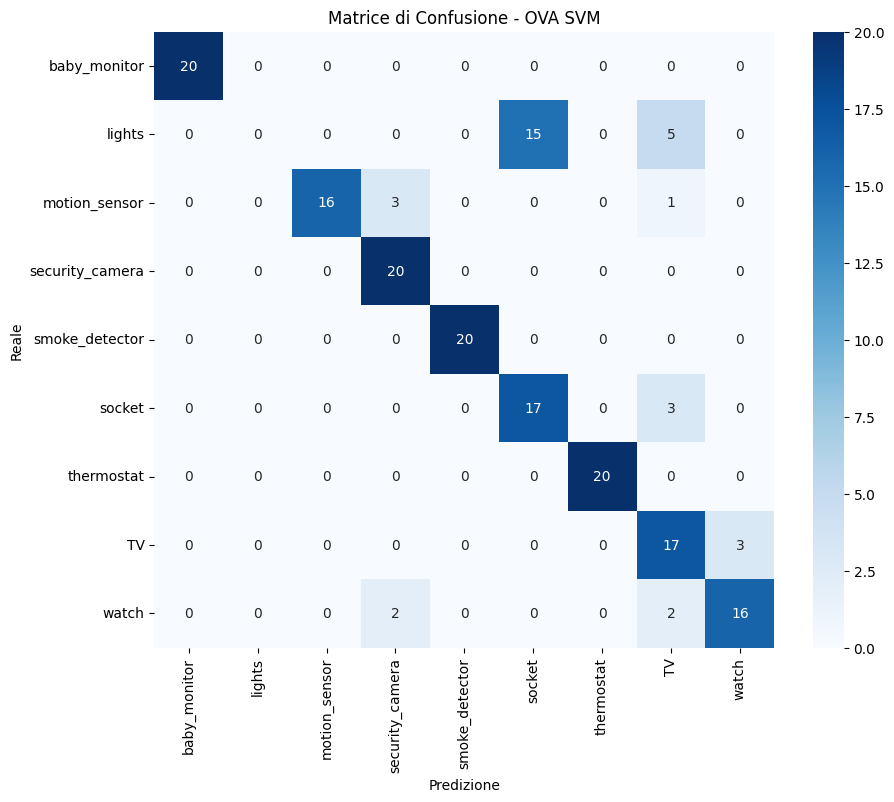

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Addestriamo il modello OVA
svm_ova = SVMMulticlassOVA(svm_class=LinearSVM, C=1.0, tol=1e-3, max_passes=10, max_iter=200)
svm_ova.fit(X_train, y_train)
# Facciamo predizioni sul test set
y_pred_ova = svm_ova.predict(X_val)

# Metriche
accuracy_linear_ova = accuracy_score(y_val, y_pred_ova)
precision_linear_ova = precision_score(y_val, y_pred_ova, average='weighted')
recall_linear_ova = recall_score(y_val, y_pred_ova, average='weighted')
f1_linear_ova = f1_score(y_val, y_pred_ova, average='weighted')
# Stampa i risultati
print(f"Accuracy OVA: {accuracy_linear_ova:.4f}")
print(f"Precision OVA: {precision_linear_ova:.4f}")
print(f"Recall OVA: {recall_linear_ova:.4f}")
print(f"F1 Score OVA: {f1_linear_ova:.4f}")

cm = confusion_matrix(y_val, y_pred_ova)
# Visualizzazione della matrice di confusione
plt.figure(figsize=(10, 8))
plt.title('Matrice di Confusione - OVA SVM')

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=devices, 
            yticklabels=devices)
plt.xlabel('Predizione')
plt.ylabel('Reale')
plt.show()


Addestramento di 36 classificatori SVM (OVO)...
Classificatore 1/36: classe 0 vs classe 1
Inizio addestramento SVM...
Addestramento completato in 13 iterazioni!
Passate finali senza cambiamenti: 10
Numero di support vectors: 2 su 120 punti (1.7%)
Norma del vettore w: 0.431890
Classificatore 2/36: classe 0 vs classe 2
Inizio addestramento SVM...
Addestramento completato in 140 iterazioni!
Passate finali senza cambiamenti: 10
Numero di support vectors: 14 su 120 punti (11.7%)
Norma del vettore w: 2.062023
Classificatore 3/36: classe 0 vs classe 3
Inizio addestramento SVM...
Addestramento completato in 146 iterazioni!
Passate finali senza cambiamenti: 10
Numero di support vectors: 21 su 120 punti (17.5%)
Norma del vettore w: 3.561940
Classificatore 4/36: classe 0 vs classe 4
Inizio addestramento SVM...
Addestramento completato in 37 iterazioni!
Passate finali senza cambiamenti: 10
Numero di support vectors: 5 su 120 punti (4.2%)
Norma del vettore w: 0.587682
Classificatore 5/36: classe 0 

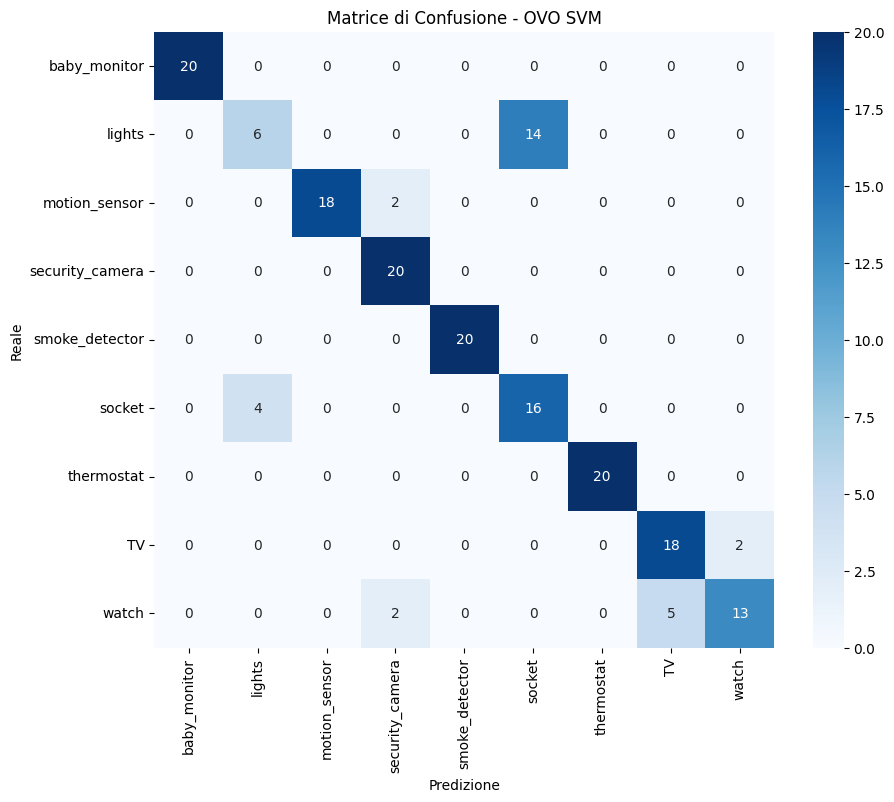

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Addestriamo il modello OVO
svm_ovo = SVMMulticlassOVO(svm_class=LinearSVM, C=1.0, tol=1e-3, max_passes=10, max_iter=200)
svm_ovo.fit(X_train, y_train)
# Facciamo predizioni sul test set
y_pred_ovo = svm_ovo.predict(X_val)

# Metriche
accuracy_linear_ovo = accuracy_score(y_val, y_pred_ovo)
precision_linear_ovo = precision_score(y_val, y_pred_ovo, average='weighted')
recall_linear_ovo = recall_score(y_val, y_pred_ovo, average='weighted')
f1_linear_ovo = f1_score(y_val, y_pred_ovo, average='weighted')
# Stampa i risultati
print(f"Accuracy OVO: {accuracy_linear_ovo:.4f}")
print(f"Precision OVO: {precision_linear_ovo:.4f}")
print(f"Recall OVO: {recall_linear_ovo:.4f}")
print(f"F1 Score OVO: {f1_linear_ovo:.4f}")

cm = confusion_matrix(y_val, y_pred_ovo)
# Visualizzazione della matrice di confusione
plt.figure(figsize=(10, 8))
plt.title('Matrice di Confusione - OVO SVM')

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=devices, 
            yticklabels=devices)
plt.xlabel('Predizione')
plt.ylabel('Reale')
plt.show()


Addestramento di 9 classificatori SVM (OVA)...
Classificatore 1/9 per classe 0 vs resto
Calcolo della matrice del kernel rbf...
Inizio addestramento SVM con kernel rbf usando SMO...
Iterazione 5, 20 cambiamenti, passes=0
Iterazione 10, 9 cambiamenti, passes=0
Iterazione 15, 6 cambiamenti, passes=0
Iterazione 20, 4 cambiamenti, passes=0
Iterazione 25, 67 cambiamenti, passes=0
Iterazione 30, 22 cambiamenti, passes=0
Iterazione 35, 20 cambiamenti, passes=0
Iterazione 40, 23 cambiamenti, passes=0
Iterazione 45, 20 cambiamenti, passes=0
Iterazione 50, 20 cambiamenti, passes=0
Iterazione 55, 14 cambiamenti, passes=0
Iterazione 60, 8 cambiamenti, passes=0
Iterazione 65, 13 cambiamenti, passes=0
Iterazione 70, 7 cambiamenti, passes=0
Iterazione 75, 45 cambiamenti, passes=0
Iterazione 80, 29 cambiamenti, passes=0
Iterazione 85, 31 cambiamenti, passes=0
Iterazione 90, 30 cambiamenti, passes=0
Iterazione 95, 15 cambiamenti, passes=0
Iterazione 100, 16 cambiamenti, passes=0
Iterazione 105, 13 camb

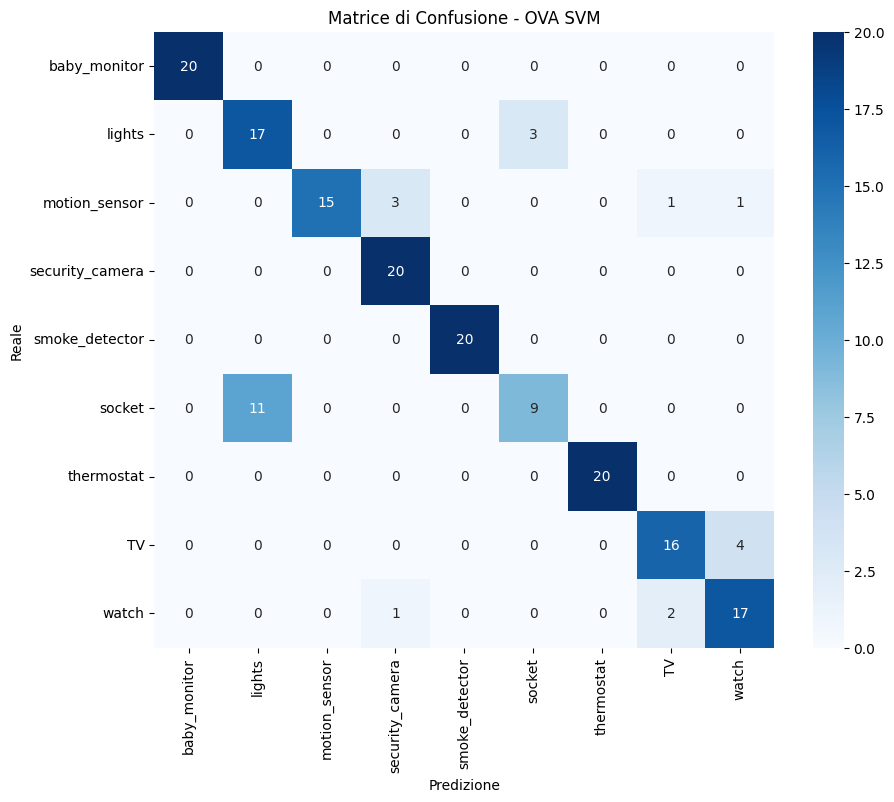

In [59]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Addestriamo il modello OVA
svm_ova = SVMMulticlassOVA(svm_class=KernelSVM, C=1.0, gamma=0.1, tol=1e-3, max_passes=10, max_iter=200)
svm_ova.fit(X_train, y_train)
# Facciamo predizioni sul test set
y_pred_ova = svm_ova.predict(X_val)

# Metriche
accuracy_kernel_ova = accuracy_score(y_val, y_pred_ova)
precision_kernel_ova = precision_score(y_val, y_pred_ova, average='weighted')
recall_kernel_ova = recall_score(y_val, y_pred_ova, average='weighted')
f1_kernel_ova = f1_score(y_val, y_pred_ova, average='weighted')
# Stampa i risultati
print(f"Accuracy OVA: {accuracy_kernel_ova:.4f}")
print(f"Precision OVA: {precision_kernel_ova:.4f}")
print(f"Recall OVA: {recall_kernel_ova:.4f}")
print(f"F1 Score OVA: {f1_kernel_ova:.4f}")

cm = confusion_matrix(y_val, y_pred_ova)
# Visualizzazione della matrice di confusione
plt.figure(figsize=(10, 8))
plt.title('Matrice di Confusione - OVA SVM')

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=devices, 
            yticklabels=devices)
plt.xlabel('Predizione')
plt.ylabel('Reale')
plt.show()


Addestramento di 36 classificatori SVM (OVO)...
Classificatore 1/36: classe 0 vs classe 1
Calcolo della matrice del kernel rbf...
Inizio addestramento SVM con kernel rbf usando SMO...
Iterazione 5, 9 cambiamenti, passes=0
Iterazione 10, 9 cambiamenti, passes=0
Iterazione 15, 1 cambiamenti, passes=0
Iterazione 20, 10 cambiamenti, passes=0
Iterazione 25, 0 cambiamenti, passes=1
Iterazione 30, 0 cambiamenti, passes=6
Addestramento completato in 34 iterazioni!
Passate finali senza cambiamenti: 10
Numero di support vectors: 16 su 120 punti (13.3%)
Classificatore 2/36: classe 0 vs classe 2
Calcolo della matrice del kernel rbf...
Inizio addestramento SVM con kernel rbf usando SMO...
Iterazione 5, 18 cambiamenti, passes=0
Iterazione 10, 14 cambiamenti, passes=0
Iterazione 15, 12 cambiamenti, passes=0
Iterazione 20, 11 cambiamenti, passes=0
Iterazione 25, 1 cambiamenti, passes=0
Iterazione 30, 28 cambiamenti, passes=0
Iterazione 35, 20 cambiamenti, passes=0
Iterazione 40, 17 cambiamenti, passes

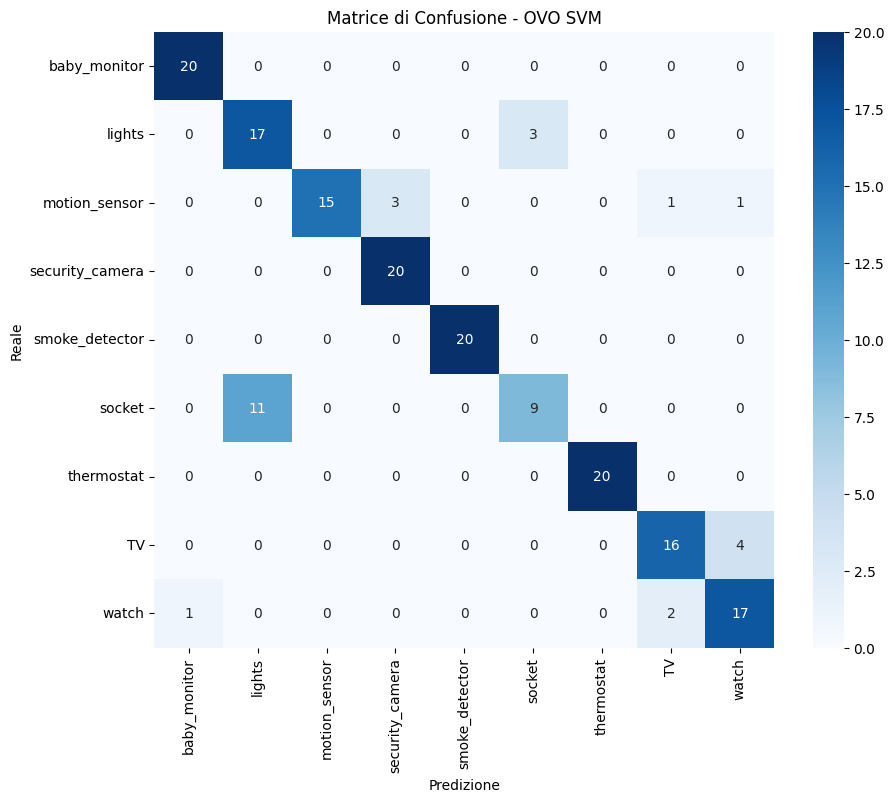

In [60]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Addestriamo il modello OVO
svm_ovo = SVMMulticlassOVO(svm_class=KernelSVM, C=1.0, gamma=0.1, tol=1e-3, max_passes=10, max_iter=200)
svm_ovo.fit(X_train, y_train)
# Facciamo predizioni sul test set
y_pred_ovo = svm_ovo.predict(X_val)

# Metriche
accuracy_kernel_ovo = accuracy_score(y_val, y_pred_ovo)
precision_kernel_ovo = precision_score(y_val, y_pred_ovo, average='weighted')
recall_kernel_ovo = recall_score(y_val, y_pred_ovo, average='weighted')
f1_kernel_ovo = f1_score(y_val, y_pred_ovo, average='weighted')
# Stampa i risultati
print(f"Accuracy OVO: {accuracy_kernel_ovo:.4f}")
print(f"Precision OVO: {precision_kernel_ovo:.4f}")
print(f"Recall OVO: {recall_kernel_ovo:.4f}")
print(f"F1 Score OVO: {f1_kernel_ovo:.4f}")

cm = confusion_matrix(y_val, y_pred_ovo)
# Visualizzazione della matrice di confusione
plt.figure(figsize=(10, 8))
plt.title('Matrice di Confusione - OVO SVM')

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=devices, 
            yticklabels=devices)
plt.xlabel('Predizione')
plt.ylabel('Reale')
plt.show()


In [61]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
# Addestramento di SVM con scikit-learn
sklearn_svm = SVC(kernel='rbf', C=1.0, gamma=0.1)
sklearn_svm.fit(X_train, y_train)

# Accuratezza
y_pred_sklearn = sklearn_svm.predict(X_val)

# Metriche
accuracy_scikit_ovo = accuracy_score(y_val, y_pred_sklearn)
precision_scikit_ovo = precision_score(y_val, y_pred_sklearn, average='weighted')
recall_scikit_ovo = recall_score(y_val, y_pred_sklearn, average='weighted')
f1_scikit_ovo = f1_score(y_val, y_pred_sklearn, average='weighted')
# Stampa i risultati
print(f"Accuracy OVO: {accuracy_scikit_ovo:.4f}")
print(f"Precision OVO: {precision_scikit_ovo:.4f}")
print(f"Recall OVO: {recall_scikit_ovo:.4f}")
print(f"F1 Score OVO: {f1_scikit_ovo:.4f}")


Accuracy OVO: 0.8556
Precision OVO: 0.8660
Recall OVO: 0.8556
F1 Score OVO: 0.8515
